# Simulations from Shaer et al. 

In [2]:
import numpy as np

def generate_dataset(n, beta=1.0, d=19, seed=None):
    rng = np.random.default_rng(seed)

    W = np.random.dirichlet(np.ones(d), size=1).flatten()
    U = np.random.dirichlet(np.ones(d), size=1).flatten()

    # Generate Z ~ N(0, I_d)
    Z = rng.normal(size=(n, d))

    # Generate X | Z ~ N(U^T Z, 1)
    X = Z @ U + rng.normal(size=n)

    # Generate Y
    epsilon = rng.normal(size=n)
    Y = (Z @ W) ** 2 + beta * X + epsilon

    # Design matrix: first column is X, remaining columns are Z
    X_design = np.column_stack((X, Z))

    return X_design, Y

In [ ]:
import os

os.chdir("..")
os.getcwd()

In [58]:
from ML_e_process import ML_e_process
from sklearn.linear_model import LassoCV

from ExponentialBet import ExponentialBet  
from AntisymmetricBet import AntisymmetricBet  # adjust import
from Sampler import DefaultSampler
from copy import deepcopy
from utils import prepare_exponential_parameters, prepare_coin_betting_parameters, g_family_cb, update_g_func_static, prepare_lambda_parameters, g_family_tanh, g_family_sign
from utils import prepare_kernel_density_parameters, g_family_kde, update_g_func_kernel_density, initialize_kde_history, generate_update_kde
from tqdm import tqdm
import pickle

etas = prepare_exponential_parameters(0.01, 5, 10)
strategy_exp = ExponentialBet(
    parameters=etas,
    exact=True
)



params_cb = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy_cb = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params_cb,
)


params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)

strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)

strategy_sign_preq = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


betting_strategies = {
    "exponential": strategy_exp,
    "coin_betting": strategy_cb,
    "tanh": strategy_tanh,
    "sign": strategy_sign,
    "sign_preq": strategy_sign_preq,

}

batch_list = [5,10,20]
j_vec = [0]
'''e_process = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=j_vec,
                 betting_strategies=betting_strategies, model=LassoCV(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )'''

### INCLUDING KDE
window_size = None
updater_kde_one_dim = generate_update_kde(resamplings=1, window_size=window_size, one_dimensional=True)
updater_kde_two_dim = generate_update_kde(resamplings=1, window_size=window_size, one_dimensional=False)

bets_js_bs = {
            j: {
                b: {
                    key: deepcopy(strategy)
                    for key, strategy in betting_strategies.items()
                }
                for b in batch_list
            }
            for j in j_vec
        }
sampdoria = [DefaultSampler(j=j) for j in j_vec]

n_init = 200
n_tot = 1000
num_seeds = 20
martingales_per_seed=[]
b_resamplings = 5
betas = [0.0]

for beta in betas:
    martingales_per_seed = []
    for seed in tqdm(range(num_seeds)):
        np.random.seed(seed)               
        X, Y = generate_dataset(n_tot, beta=beta, d=19, seed=None) 

        q, q_tilde = initialize_kde_history(X[:n_init], Y[:n_init].ravel(), sampdoria, j_vec, batch_list, resamplings=b_resamplings, model = LassoCV())

        for j in j_vec:
            for b in batch_list:
                params_kde = prepare_kernel_density_parameters()
                model_for_history = LassoCV()
                
                past_qs = list(zip(q[b], q_tilde[b][j]))
                
                strategy_kde_1d = AntisymmetricBet(
                    g_family= g_family_kde, 
                    update_g_func = updater_kde_one_dim, 
                    parameters=params_kde,
                    prequential=True,
                    past_qs = past_qs
                )

                strategy_kde_2d = AntisymmetricBet(
                                    g_family= g_family_kde, 
                                    update_g_func = updater_kde_two_dim, 
                                    parameters=params_kde,
                                    prequential=True,
                                    past_qs = past_qs
                                )
                bets_js_bs[j][b]["kde_1d"] = strategy_kde_1d
                bets_js_bs[j][b]["kde_2d"] = strategy_kde_2d


        e_process = ML_e_process(batch_list=batch_list, n_init=n_init, b_resamplings=b_resamplings, study_j=j_vec,
                        betting_strategies=betting_strategies, model=LassoCV(),
                        #learn_conditional_distribution=get_data_statistics,
                        samplers=None, #sampling_args={}
                        learn_conditional_distribution=True,
                        optional_stopping=True, 
                        bets_js_bs=bets_js_bs
                        )

        martingales_per_seed.append(e_process.martingales(X, y=Y))
    with open(f'martingales_per_seed_beta_{beta}.pkl', 'wb') as f:
        pickle.dump(martingales_per_seed, f)


100%|██████████| 20/20 [22:59<00:00, 68.99s/it]


In [60]:
martingales_per_seed_beta = []
betas = [0.0,0.1,0.5]
for beta in betas:
    with open(f'martingales_per_seed_beta_{beta}.pkl', 'rb') as f:
        martingales_per_seed_beta.append(pickle.load(f))

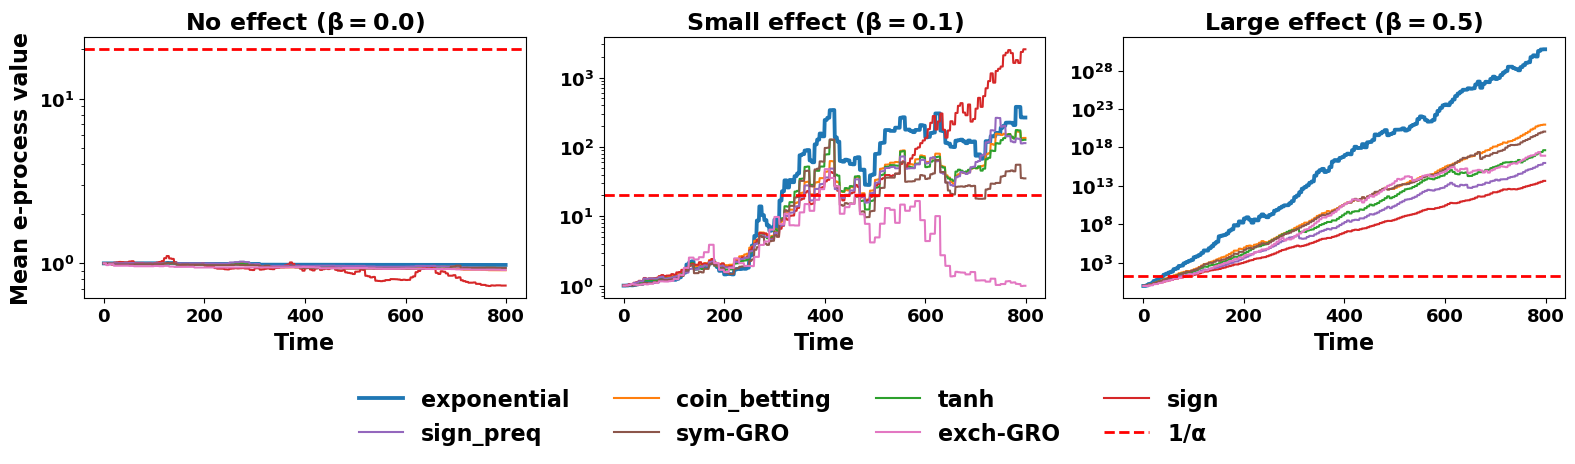

In [68]:
import matplotlib.pyplot as plt
import numpy as np

alpha = 0.05
j = 0
strategy_names = ['exponential', 'coin_betting', 'tanh', 'sign', 'sign_preq', 'kde_1d', 'kde_2d']
strategy_name_dict = {'exponential':'exponential', 'coin_betting':'coin_betting', 'tanh':'tanh', 'sign':'sign', 'sign_preq':'sign_preq', 'kde_1d':'sym-GRO', 'kde_2d':'exch-GRO'}

# Non-antisymmetric e-variables are drawn thicker to set them apart
non_antisymmetric = {'exponential'}

titles = [
    rf"No effect ($\beta = {betas[0]}$)",
    rf"Small effect ($\beta = {betas[1]}$)",
    rf"Large effect ($\beta = {betas[2]}$)",
]

# Larger, bold text everywhere (titles, axis labels, ticks, legend, math text)
plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 16,
    "mathtext.default": "bf",  # bold math, e.g. log-scale tick labels like 10^2
})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))  # no sharey: separate scale per panel

for ax, martingales_per_seed, title in zip(axes, martingales_per_seed_beta, titles):
    for strategy_name in strategy_names:
        # average over seeds (and batch sizes)
        mean_eprocess = np.mean(
            [martingales_per_seed[i][strategy_name][batch_size][j][n_init:]
             for i in range(num_seeds) for batch_size in batch_list],
            axis=0,
        )
        lw = 2.75 if strategy_name in non_antisymmetric else 1.5
        ax.plot(mean_eprocess, label=strategy_name_dict[strategy_name], linewidth=lw)

    ax.axhline(y=1 / alpha, color="red", linestyle="--", linewidth=2, label=r"$1/\alpha$")
    ax.set_yscale("log")
    ax.set_xlabel("Time")
    ax.set_title(title)

# y-label only once, on the leftmost panel
axes[0].set_ylabel("Mean e-process value", fontweight="bold")

# Shared legend in 2 rows: first half on row 1, second half on row 2.
# Matplotlib fills legends column by column, so reorder to get row-by-row order.
handles, labels = axes[0].get_legend_handles_labels()
nrows = 2
ncol = int(np.ceil(len(labels) / nrows))
order = [r * ncol + c for c in range(ncol) for r in range(nrows) if r * ncol + c < len(labels)]
fig.legend(
    [handles[k] for k in order], [labels[k] for k in order],
    loc="lower center",
    ncol=ncol,
    bbox_to_anchor=(0.5, -0.06),
    frameon=False,
)

plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()